In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [ ]:
# load the data that was have been provided by the project explanation
data = pd.read_csv('/aol_data.csv')
print(data)

     M1    M2    M3    M4    M5    M6    M7    M8    M9   M10  ...   M135  \
0  1863  1614  2570  1685  2101  1811  2457  2171  2134  2502  ...  14917   

    M136   M137   M138   M139   M140   M141   M142   M143   M144  
0  15046  15556  15893  16388  16782  16716  17033  16896  17689  

[1 rows x 144 columns]


In [ ]:
data.isnull().sum()

,0
M1,0
M2,0
M3,0
M4,0
M5,0
...,...
M140,0
M141,0
M142,0
M143,0


In [ ]:
# based on the data that we have printed, we have 144 columns
months = list(range(1, 145))
production = data.iloc[0, :].values

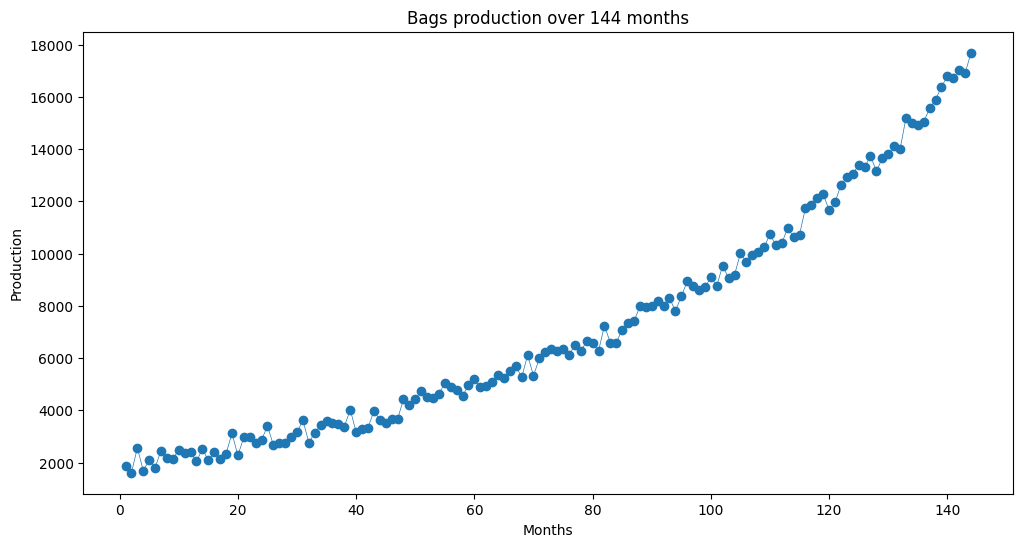

In [ ]:
# visualization for bags production over 144 month
plt.figure(figsize=(12,6))
plt.plot(months, production, marker='o', linestyle='-', linewidth = 0.5)
plt.title('Bags production over 144 months')
plt.xlabel('Months')
plt.ylabel('Production')
plt.show()

Nomor 1

In [ ]:
degree = 3
coefficients = np.polyfit(months, production, degree)
polynomial = np.poly1d(coefficients)

y_pred = polynomial(months)

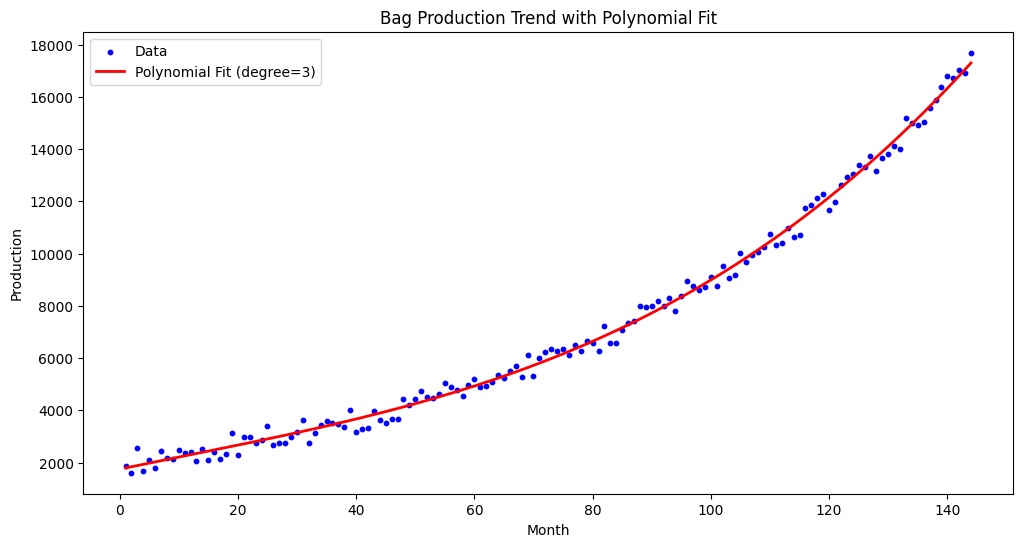

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(months, production, color='blue', label='Data', s = 10)
plt.plot(months, y_pred, color='red', label=f'Polynomial Fit (degree={degree})', linewidth=2)
plt.title('Bag Production Trend with Polynomial Fit')
plt.xlabel('Month')
plt.ylabel('Production')
plt.legend()
plt.show()

Nomor 2

In [ ]:
print("Polynomial Equation:")
print(polynomial)

Polynomial Equation:
          3          2
0.003863 x - 0.1344 x + 47.22 x + 1749


In [ ]:
# the assesment needed a three-digits precision so we rounded up the equation
coefficients = [0.003863, -0.1344, 47.22, 1749]
rounded_coefficients = np.round(coefficients, 3)
polynomial = np.poly1d(rounded_coefficients)

print("Polynomial Equation:")
print(polynomial)

Polynomial Equation:
       3         2
0.004 x - 0.134 x + 47.22 x + 1749


In [ ]:
# Calculate R-squared to evaluate the model's perfomance
ss_total = np.sum((production - np.mean(production)) ** 2)
ss_residual = np.sum((production - y_pred) ** 2)
r2 = 1 - (ss_residual / ss_total)

print(f"Model Accuracy: R^2 = {r2:.3f}")

Model Accuracy: R^2 = 0.996


In [ ]:
mse = np.mean((production - y_pred) ** 2)
print(f'Model Accuracy: Mean Squared Error = {mse:.3f}')

rmse = np.sqrt(mse)
print(f'Model Accuracy: Root Mean Squared Error = {rmse:.3f}')

Model Accuracy: Mean Squared Error = 83195.127
Model Accuracy: Root Mean Squared Error = 288.436


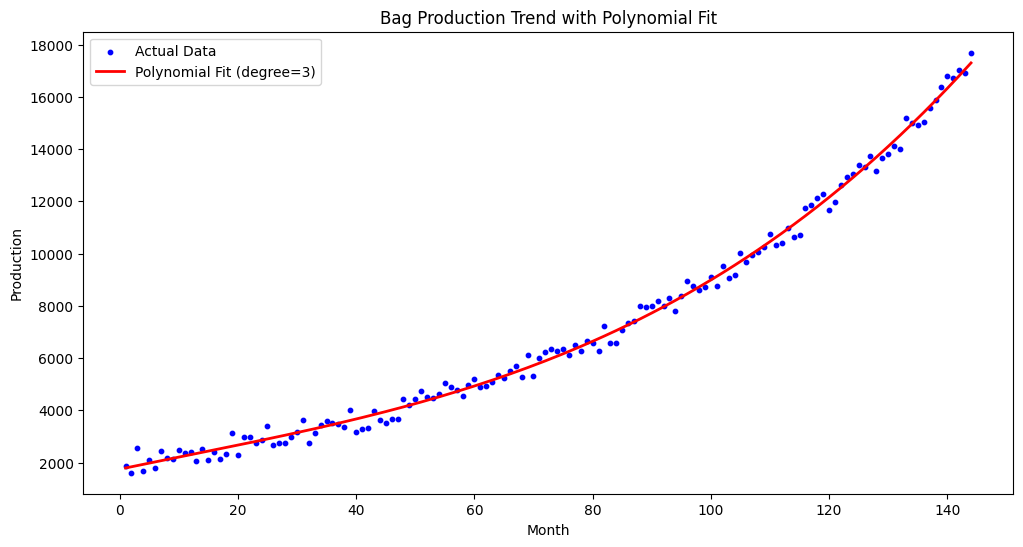

In [ ]:
# Plot the data and polynomial fit
plt.figure(figsize=(12, 6))
plt.scatter(months, production, color='blue', label='Actual Data', s=10)
plt.plot(months, y_pred, color='red', label=f'Polynomial Fit (degree={degree})', linewidth=2)
plt.title('Bag Production Trend with Polynomial Fit')
plt.xlabel('Month')
plt.ylabel('Production')
plt.legend()
plt.show()

Nomor 3

In [ ]:
coefficients = [0.003863, -0.1344, 47.22, 1749]  # Given polynomial coefficients
rounded_coefficients = np.round(coefficients, 3)
polynomial = np.poly1d(rounded_coefficients)

print("Polynomial Equation:")
print(polynomial)

Polynomial Equation:
       3         2
0.004 x - 0.134 x + 47.22 x + 1749


In [ ]:
# the equation that we needed to solve
def equation(x):
    return polynomial(x) - 25000

# derivative of the equation
def derivative(x):
    return np.polyder(polynomial)(x)

# newton-rhapson method
def newton_raphson(equation, derivative, initial_guess, tolerance=1e-6, max_iterations=1000):
    x = initial_guess
    for i in range(max_iterations):
        fx = equation(x)
        fpx = derivative(x)

        if abs(fx) < tolerance:
            return x

        x = x - fx / fpx

    raise ValueError("Newton-Raphson method did not converge")

# first guess
guess = 0

# finding the month where production exceeds 25000
month_exceed = newton_raphson(equation, derivative, guess)

# because a warehouse needed 13 months to be built so we need to substract 13
start_build = month_exceed - 13

# round up the integer
month_exceed = max(1, round(month_exceed))
start_build = max(1, round(start_build))

print(f"Production will exceed 25000 in month {month_exceed}.")
print(f"so EGIER should start building a new warehouse in month {start_build}.")

Production will exceed 25000 in month 168.
so EGIER should start building a new warehouse in month 155.


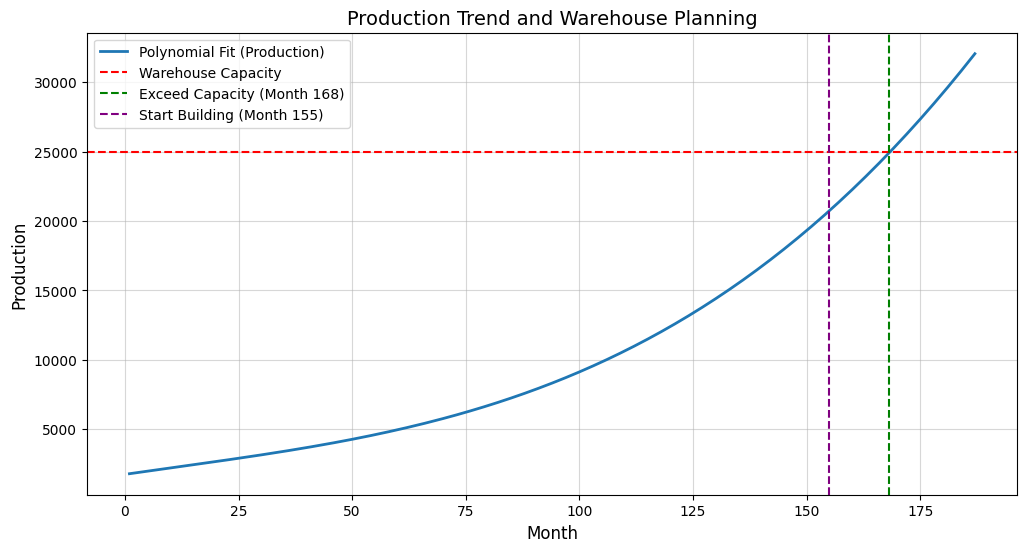

In [ ]:
months = np.arange(1, exceed_month + 20)
production = polynomial(months)

plt.figure(figsize=(12, 6))
plt.plot(months, production, label='Polynomial Fit (Production)', linewidth=2)
plt.axhline(25000, color='red', linestyle='--', label='Warehouse Capacity')
plt.axvline(exceed_month, color='green', linestyle='--', label=f'Exceed Capacity (Month {exceed_month})')
plt.axvline(start_building_month, color='purple', linestyle='--', label=f'Start Building (Month {start_building_month})')
plt.title('Production Trend and Warehouse Planning', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Production', fontsize=12)
plt.legend()
plt.grid(alpha=0.5)
plt.show()